In [1]:
import cv2
import fitz
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

In [2]:
PDF_PATH    = Path('data/query_planning.pdf')
TARGET_SIZE = (128, 128)   # (W, H) — identical to transcribe.py and multimodal_hmm.ipynb

In [3]:
# ── Load slides — same pipeline as transcribe.py / multimodal_hmm.ipynb ───────
# Step 1: fitz page → RGB array → grayscale → resize → uint8   (slides_raw)
# Step 2: per-image z-score normalisation                        (slides_norm)

def normalize_gray(arr: np.ndarray) -> np.ndarray:
    a = arr.astype(np.float32)
    s = a.std()
    return (a - a.mean()) / (s if s > 0 else 1.0)

slides_raw  = []   # list of (H, W) uint8
slides_norm = []   # list of (H, W) float32  z-scores

pdf = fitz.open(str(PDF_PATH))
n_slides = len(pdf)

for page in pdf:
    pix = page.get_pixmap(dpi=72)
    rgb = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    raw  = cv2.resize(gray, TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4)
    slides_raw.append(raw)
    slides_norm.append(normalize_gray(raw))

pdf.close()

slides_raw  = np.stack(slides_raw,  axis=0)   # (S, H, W)  uint8
slides_norm = np.stack(slides_norm, axis=0)   # (S, H, W)  float32

print(f'Loaded {n_slides} slides')
print(f'slides_raw  shape: {slides_raw.shape}  dtype: {slides_raw.dtype}')
print(f'slides_norm shape: {slides_norm.shape}  dtype: {slides_norm.dtype}')
print(f'Raw  range : [{slides_raw.min()},  {slides_raw.max()}]')
print(f'Norm range : [{slides_norm.min():.2f},  {slides_norm.max():.2f}]')

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

Loaded 114 slides
slides_raw  shape: (114, 128, 128)  dtype: uint8
slides_norm shape: (114, 128, 128)  dtype: float32
Raw  range : [0,  255]
Norm range : [-8.74,  1.38]


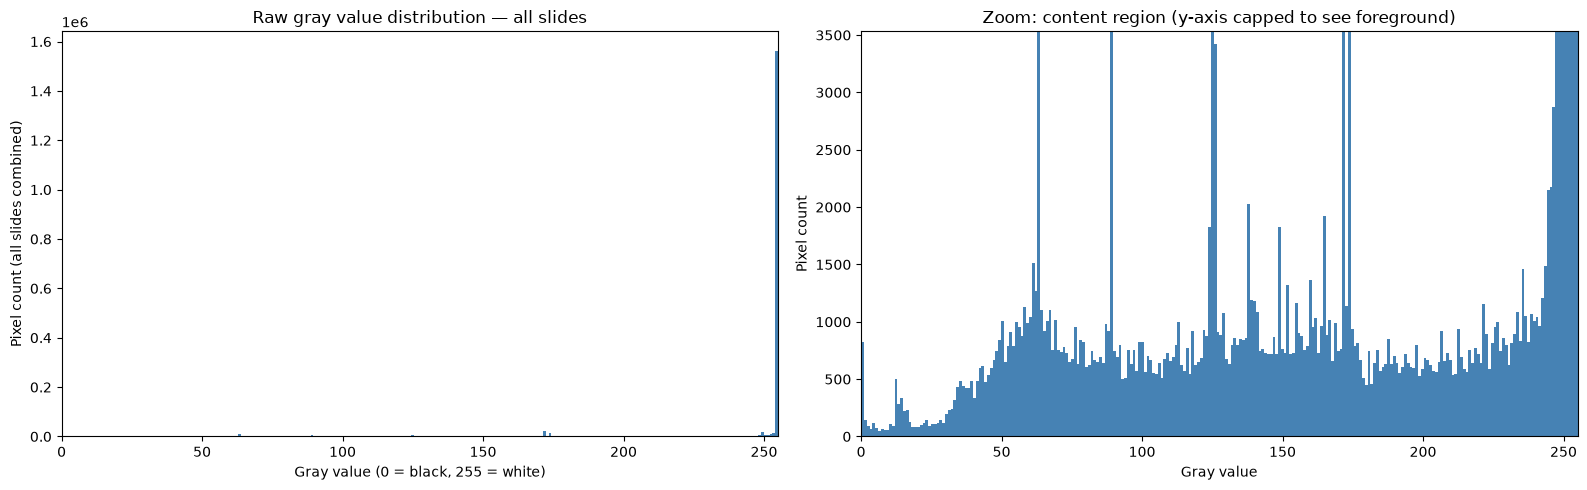

Top-5 most common raw gray values:
  value=254-255  count=1,563,326
  value=171-172  count=24,079
  value=249-250  count=16,566
  value=253-254  count=13,394
  value=173-174  count=12,498


In [4]:
# ── Histogram of RAW gray values across all slides ─────────────────────────────
# Flatten all pixels from all slides into one array for a global view.
# Expected: a large spike near 255 (white background) and a smaller cluster
# near 0 (dark text / graphics).  The valley between them is the threshold
# candidate for foreground/background separation.

all_raw = slides_raw.ravel()   # (S * H * W,)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: full histogram 0-255
ax = axes[0]
counts, edges, _ = ax.hist(all_raw, bins=256, range=(0, 255),
                            color='steelblue', edgecolor='none')
ax.set_xlabel('Gray value (0 = black, 255 = white)')
ax.set_ylabel('Pixel count (all slides combined)')
ax.set_title('Raw gray value distribution — all slides')
ax.set_xlim(0, 255)

# Right: zoom into the dark / mid-tone region to see content pixels
ax = axes[1]
ax.hist(all_raw, bins=256, range=(0, 255), color='steelblue', edgecolor='none')
ax.set_xlabel('Gray value')
ax.set_ylabel('Pixel count')
ax.set_title('Zoom: content region (y-axis capped to see foreground)')
# Cap y-axis to the 95th percentile of bin counts to not be dominated by the white spike
ax.set_ylim(0, np.percentile(counts[counts > 0], 95))
ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()

# Print the top-5 most common pixel values
top5_idx = np.argsort(counts)[-5:][::-1]
print('Top-5 most common raw gray values:')
for i in top5_idx:
    print(f'  value={int(edges[i])}-{int(edges[i+1])}  count={int(counts[i]):,}')

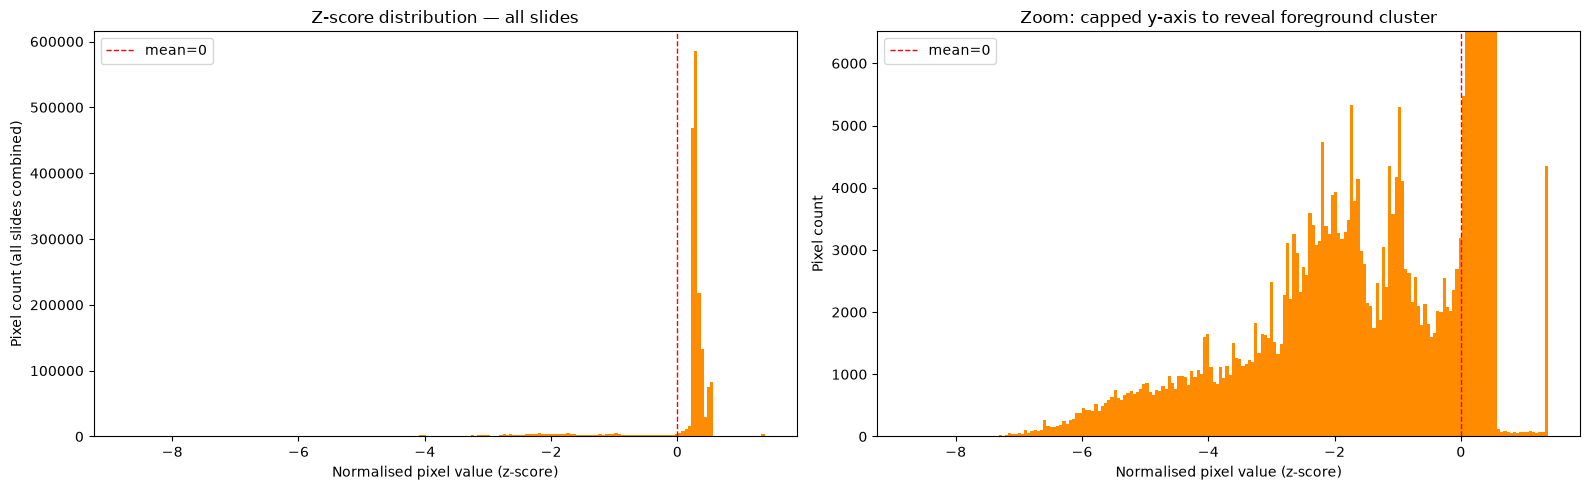

Top-5 most common z-score bins:
  z ∈ [0.268, 0.319]  count=586,138
  z ∈ [0.217, 0.268]  count=467,909
  z ∈ [0.319, 0.369]  count=217,784
  z ∈ [0.369, 0.420]  count=132,838
  z ∈ [0.521, 0.572]  count=82,896


In [5]:
# ── Histogram of NORMALISED z-score values across all slides ───────────────────
# After per-image z-score normalisation the white background maps to a specific
# z-score cluster.  This shows where background and foreground pixels fall
# in the normalised space that the Gaussian model actually operates in.

all_norm = slides_norm.ravel()

z_min, z_max = float(all_norm.min()), float(all_norm.max())
n_bins = 200

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
nc, ne, _ = ax.hist(all_norm, bins=n_bins, range=(z_min, z_max),
                    color='darkorange', edgecolor='none')
ax.set_xlabel('Normalised pixel value (z-score)')
ax.set_ylabel('Pixel count (all slides combined)')
ax.set_title('Z-score distribution — all slides')
ax.axvline(0, color='red', lw=1, ls='--', label='mean=0')
ax.legend()

ax = axes[1]
ax.hist(all_norm, bins=n_bins, range=(z_min, z_max),
        color='darkorange', edgecolor='none')
ax.set_xlabel('Normalised pixel value (z-score)')
ax.set_ylabel('Pixel count')
ax.set_title('Zoom: capped y-axis to reveal foreground cluster')
ax.set_ylim(0, np.percentile(nc[nc > 0], 95))
ax.axvline(0, color='red', lw=1, ls='--', label='mean=0')
ax.legend()

plt.tight_layout()
plt.show()

# Where does the background cluster sit?
top5_idx = np.argsort(nc)[-5:][::-1]
print('Top-5 most common z-score bins:')
for i in top5_idx:
    print(f'  z ∈ [{ne[i]:.3f}, {ne[i+1]:.3f}]  count={int(nc[i]):,}')

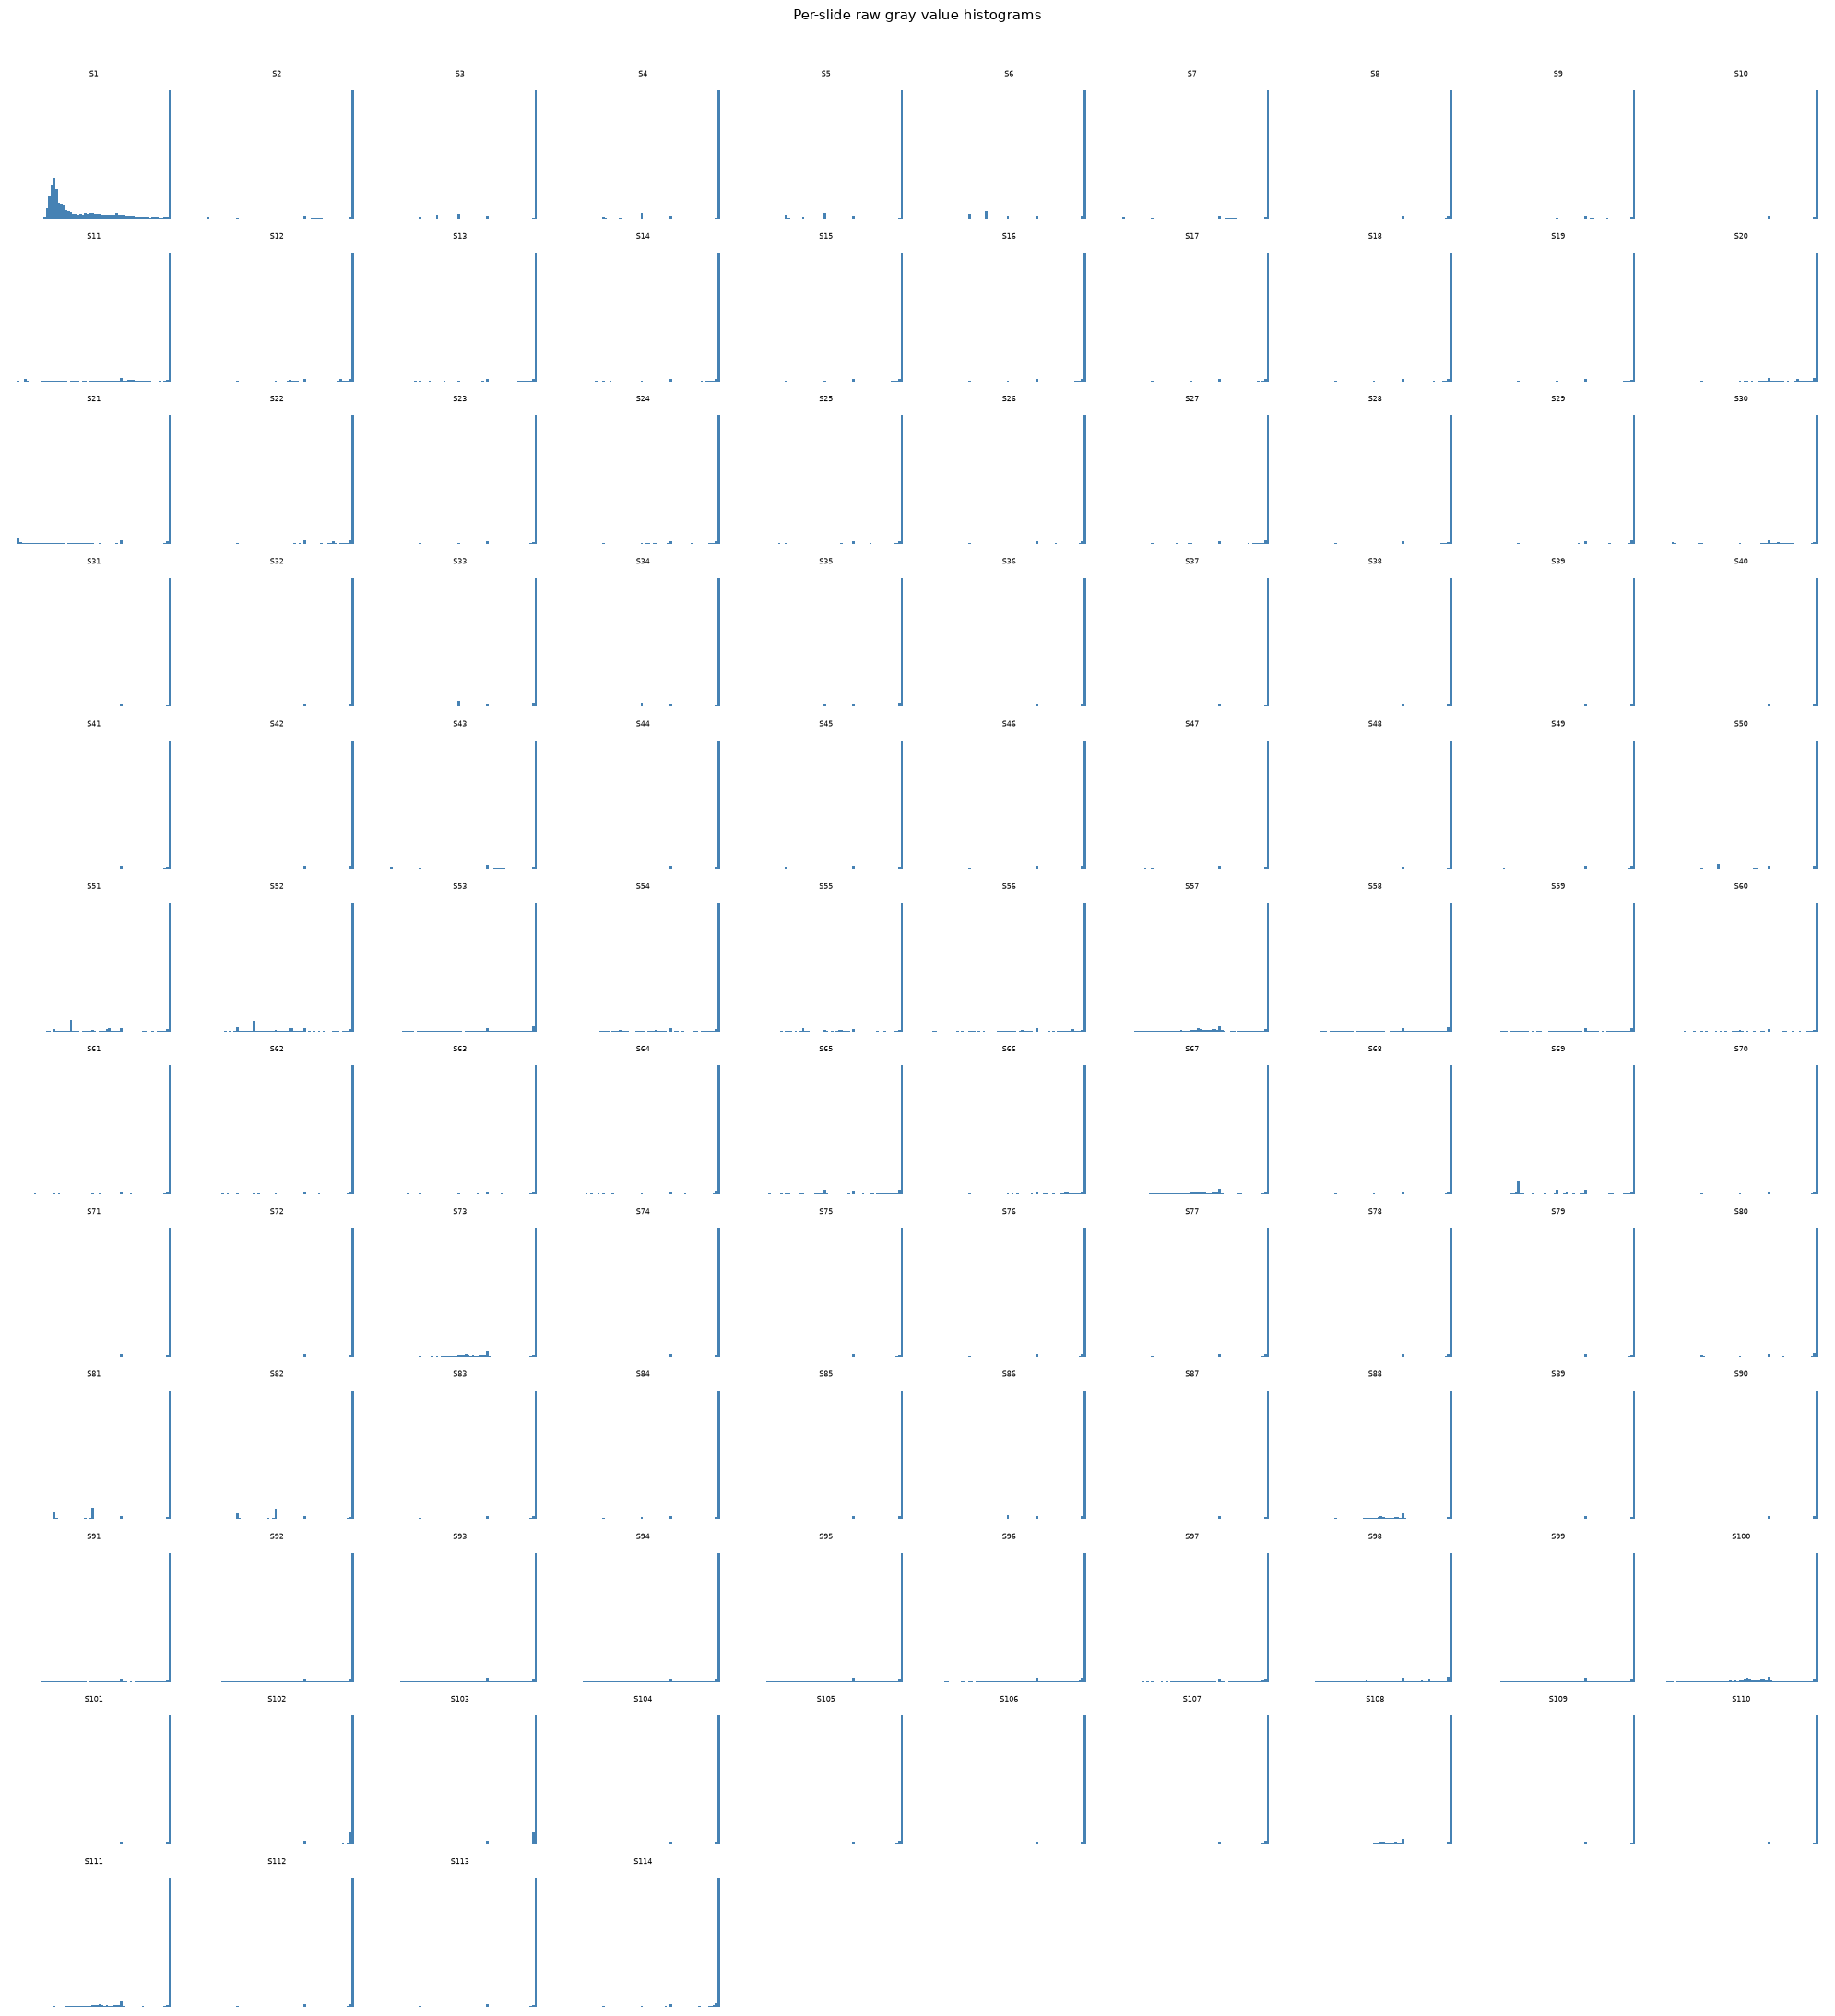

In [6]:
# ── Per-slide raw histogram grid ───────────────────────────────────────────────
# Each small subplot shows one slide's gray value histogram.
# Useful for spotting outlier slides (very dark, very colourful, etc.).

COLS = 10
ROWS = int(np.ceil(n_slides / COLS))

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 2, ROWS * 1.8))
axes = axes.ravel()

for s in range(n_slides):
    axes[s].hist(slides_raw[s].ravel(), bins=64, range=(0, 255),
                 color='steelblue', edgecolor='none')
    axes[s].set_title(f'S{s+1}', fontsize=6)
    axes[s].axis('off')

for s in range(n_slides, len(axes)):
    axes[s].set_visible(False)

fig.suptitle('Per-slide raw gray value histograms', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

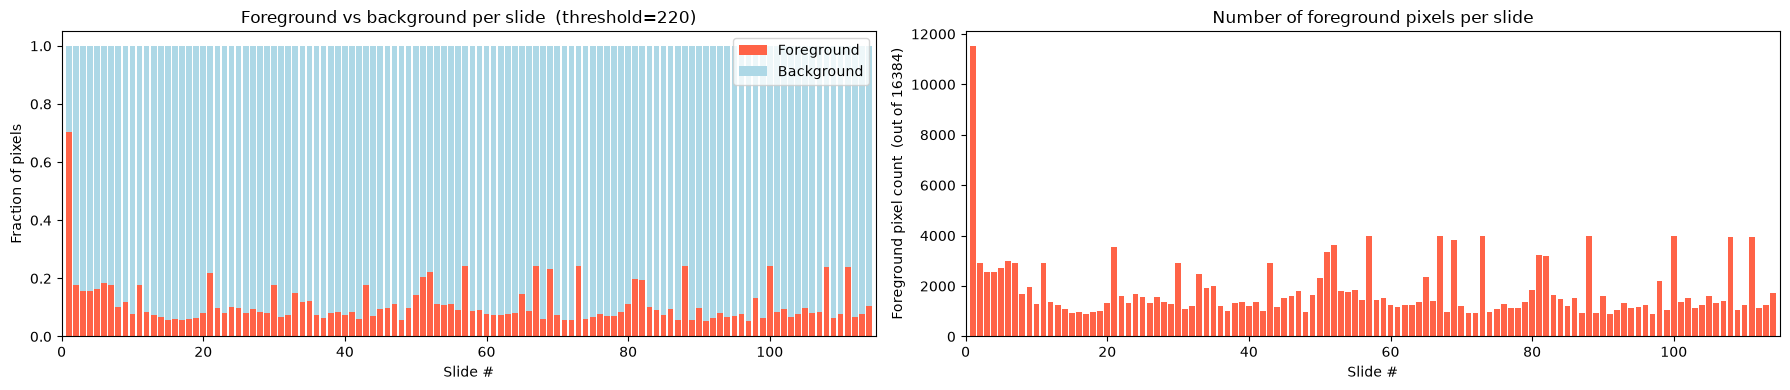

Threshold: raw gray > 220 → background
Overall background fraction: 88.8%
Overall foreground fraction: 11.2%
Slide with MOST foreground : S1  (70.4% foreground)
Slide with LEAST foreground: S91  (5.4% foreground)


In [7]:
# ── Background pixel fraction per slide ────────────────────────────────────────
# Based on the raw histogram, pick a threshold T such that raw > T = background.
# Adjust T to the valley you observe in the histogram above.

BG_THRESHOLD = 220   # ← tune this after looking at cell_04

bg_fraction  = (slides_raw > BG_THRESHOLD).mean(axis=(1, 2))   # fraction per slide
fg_fraction  = 1.0 - bg_fraction
fg_px_count  = (slides_raw <= BG_THRESHOLD).sum(axis=(1, 2))   # absolute foreground pixels
total_px     = TARGET_SIZE[0] * TARGET_SIZE[1]

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

ax = axes[0]
ax.bar(range(1, n_slides+1), fg_fraction, color='tomato', label='Foreground')
ax.bar(range(1, n_slides+1), bg_fraction, bottom=fg_fraction,
       color='lightblue', label='Background')
ax.set_xlabel('Slide #')
ax.set_ylabel('Fraction of pixels')
ax.set_title(f'Foreground vs background per slide  (threshold={BG_THRESHOLD})')
ax.legend()
ax.set_xlim(0, n_slides+1)

ax = axes[1]
ax.bar(range(1, n_slides+1), fg_px_count, color='tomato')
ax.set_xlabel('Slide #')
ax.set_ylabel(f'Foreground pixel count  (out of {total_px})')
ax.set_title('Number of foreground pixels per slide')
ax.set_xlim(0, n_slides+1)

plt.tight_layout()
plt.show()

print(f'Threshold: raw gray > {BG_THRESHOLD} → background')
print(f'Overall background fraction: {bg_fraction.mean()*100:.1f}%')
print(f'Overall foreground fraction: {fg_fraction.mean()*100:.1f}%')
print(f'Slide with MOST foreground : S{np.argmax(fg_fraction)+1}  '
      f'({fg_fraction.max()*100:.1f}% foreground)')
print(f'Slide with LEAST foreground: S{np.argmin(fg_fraction)+1}  '
      f'({fg_fraction.min()*100:.1f}% foreground)')

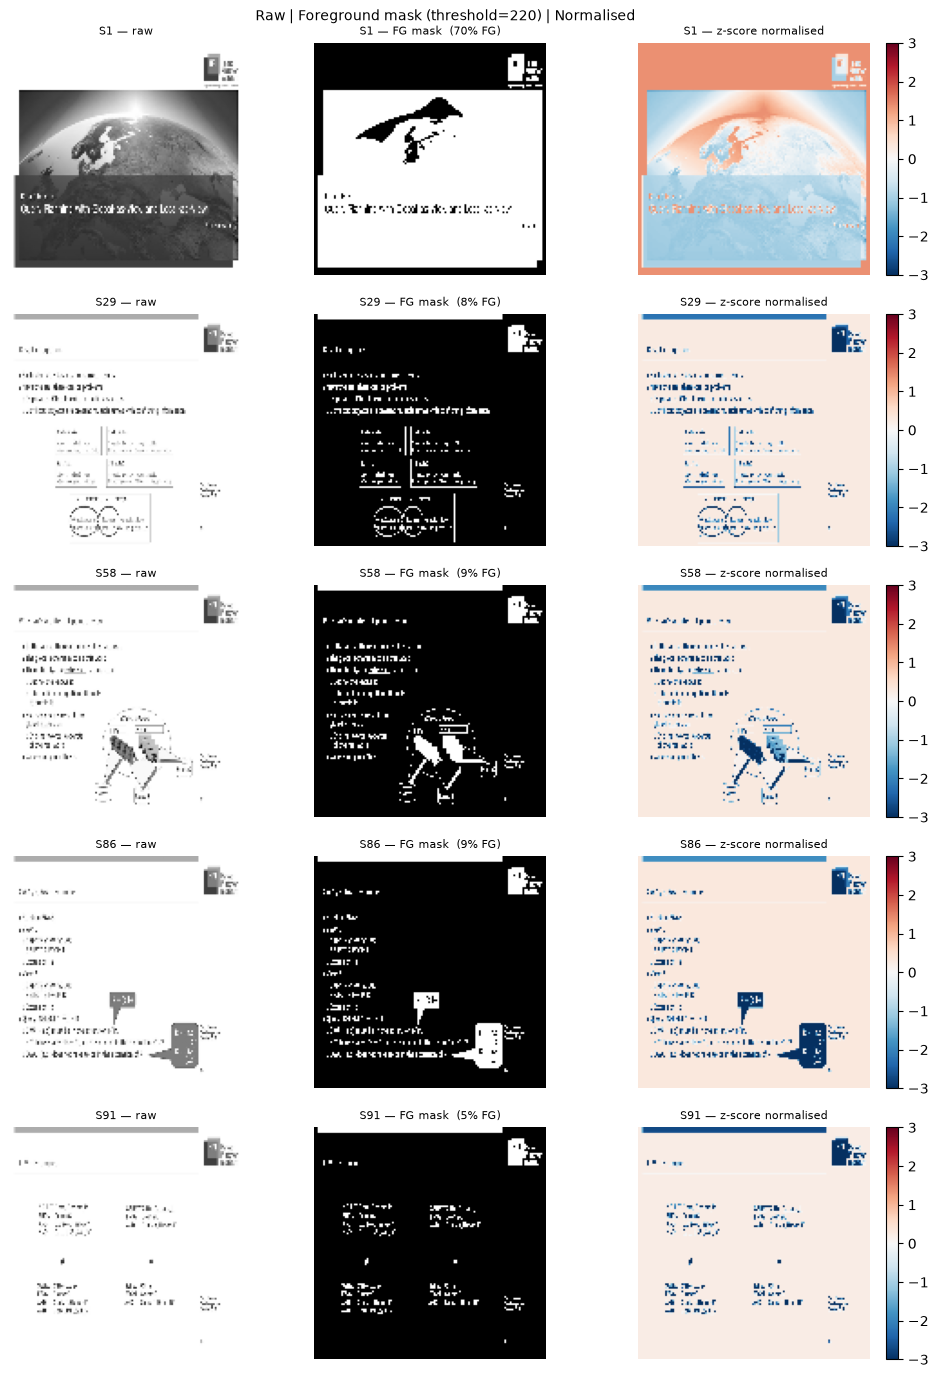

In [8]:
# ── Visualise foreground mask on sample slides ─────────────────────────────────
# Shows the raw slide, the foreground mask, and the normalised slide side-by-side
# for a few selected slides (most-fg, least-fg, and a few in between).

sample_idx = sorted(set([
    np.argmax(fg_fraction),        # most foreground
    np.argmin(fg_fraction),        # least foreground
    n_slides // 4,
    n_slides // 2,
    3 * n_slides // 4,
]))

fig, axes = plt.subplots(len(sample_idx), 3,
                          figsize=(10, 2.8 * len(sample_idx)))

for row, s in enumerate(sample_idx):
    raw  = slides_raw[s]
    norm = slides_norm[s]
    mask = (raw <= BG_THRESHOLD).astype(np.uint8) * 255   # white = foreground

    axes[row, 0].imshow(raw,  cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title(f'S{s+1} — raw', fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask, cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title(
        f'S{s+1} — FG mask  ({fg_fraction[s]*100:.0f}% FG)', fontsize=8)
    axes[row, 1].axis('off')

    im = axes[row, 2].imshow(norm, cmap='RdBu_r',
                              vmin=-3, vmax=3)
    axes[row, 2].set_title(f'S{s+1} — z-score normalised', fontsize=8)
    axes[row, 2].axis('off')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.04)

fig.suptitle(f'Raw | Foreground mask (threshold={BG_THRESHOLD}) | Normalised',
             fontsize=10)
plt.tight_layout()
plt.show()